<a href="https://colab.research.google.com/github/Carolina51908/machine-learning/blob/main/series/series_tiempo_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Presentado por Jenny Carolina Choco

# Prediciendo el Futuro: Machine Learning aplicado a Series Temporales

¡Hola a todos! Bienvenidos a este laboratorio.

Hasta ahora han construido modelos para saber si un cliente será moroso o si un paciente tiene una enfermedad o no, basándose en sus síntomas actuales. Pero hoy vamos a enfrentar uno de los problemas más críticos en cualquier industria aprovechando al máximo los datos del pasado para **predecir el futuro**.

### El Caso de Estudio: La Crisis de Camas Hospitalarias
Imagina que eres el Científico de Datos principal de una red de hospitales en Colombia. Tu Director Médico te llama y te dice: *"Necesito saber cuál será la demanda mensual de camas de Cuidados Intensivos (UCI) e insumos críticos para los próximos 3 años"*.

Si tu modelo predice una demanda muy baja, el hospital no comprará suficientes insumos y **habrá una crisis sanitaria** (pacientes sin atender). Si tu modelo predice una demanda altísima, el hospital gastará millones en camas que estarán vacías, **desperdiciando presupuesto** que pudo usarse en investigación.

Hoy aprenderemos cómo usar algoritmos de Machine Learning tradicionales (que ya conocen) para resolver este problema temporal usando la genial librería `skforecast`.

In [3]:
# Importamos las herramientas de siempre
import pandas as pd
import matplotlib.pyplot as plt


!pip install skforecast

# Usaremos un dataset real integrado en skforecast (Originalmente consumo de agua/recursos).
# Lo trataremos como nuestra demanda de recursos críticos hospitalarios.
from skforecast.datasets import fetch_dataset

datos = fetch_dataset(name='h2o')
datos = datos.rename(columns={'x': 'demanda_recursos'})
datos.index.name = 'fecha'
datos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.7/415.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.5 MB/s eta 0:00:00


╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 1 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

,demanda_recursos
fecha,
1991-07-01,0.429795
1991-08-01,0.400906
1991-09-01,0.432159
1991-10-01,0.492543
1991-11-01,0.502369
...,...
2008-02-01,0.761822
2008-03-01,0.649435
2008-04-01,0.827887


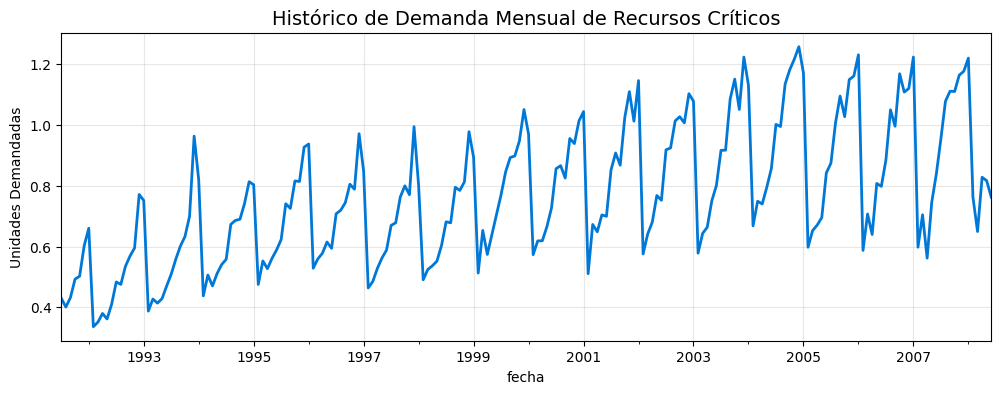

In [4]:
# REGLA #1 DE SERIES DE TIEMPO: ¡Siempre mira tus datos primero!
fig, ax = plt.subplots(figsize=(12, 4))
datos['demanda_recursos'].plot(ax=ax, color='#0078D7', linewidth=2)
ax.set_title('Histórico de Demanda Mensual de Recursos Críticos', fontsize=14)
ax.set_ylabel('Unidades Demandadas')
plt.grid(True, alpha=0.3)
plt.show()

### 🤔 La Intuición: ¿Cómo le enseñamos el 'tiempo' a un Random Forest?

Si observan la gráfica de arriba, verán picos y valles regulares. Hay estacionalidad (quizás en invierno hay más enfermedades respiratorias).

El problema es que un `RandomForestRegressor` o un `LinearRegression` **no entienden el tiempo**. Solo entienden matrices: variables predictoras ($X$) y una variable objetivo ($y$).

¿Cómo transformamos una sola línea de tiempo en una tabla?
La respuesta es hermosa y sencilla: **Usamos el pasado como las características del presente (Lags o Rezagos)**.

Si queremos predecir cuántas camas necesitaremos hoy ($y_t$), usaremos como variables predictoras:
- Las camas de hace 1 mes ($y_{t-1}$)
- Las camas de hace 2 meses ($y_{t-2}$)
- Las camas de hace 3 meses ($y_{t-3}$)

Deslizamos una "ventana" por nuestros datos, y mágicamente tenemos un problema tabular clásico. `skforecast` hace esto por nosotros.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterRecursive

# 1. Separamos el pasado (para aprender) del futuro (para evaluarnos)
# NUNCA usen un split aleatorio aquí, estarían viajando al futuro para predecir el pasado.
fin_entrenamiento = '2005-01-01'
datos_train = datos.loc[:fin_entrenamiento]
datos_test  = datos.loc[fin_entrenamiento:]

print(f"Meses para entrenar : {len(datos_train)}")
print(f"Meses para evaluar  : {len(datos_test)}")


Meses para entrenar : 163
Meses para evaluar  : 42


/tmp/ipykernel_206/1679303185.py:3: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster = ForecasterRecursive(


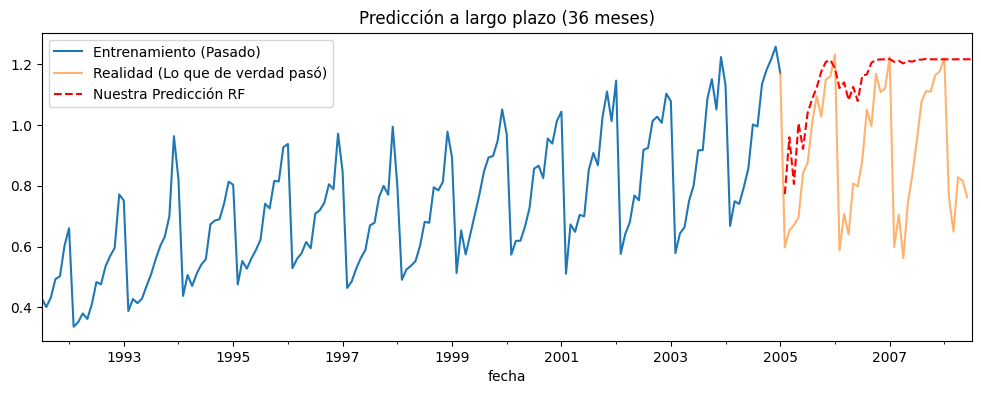

In [6]:

# 2. Creamos el Oráculo (Forecaster)
# Le decimos: "Usa un Random Forest, y mira los últimos 15 meses (lags=15) para predecir el siguiente".
forecaster = ForecasterRecursive(
                regressor = RandomForestRegressor(random_state=42),
                lags      = 15
             )

# 3. Entrenamos y Predecimos
forecaster.fit(y=datos_train['demanda_recursos'])
predicciones = forecaster.predict(steps=len(datos_test))

# 4. Evaluamos visualmente
fig, ax = plt.subplots(figsize=(12, 4))
datos_train['demanda_recursos'].plot(ax=ax, label='Entrenamiento (Pasado)')
datos_test['demanda_recursos'].plot(ax=ax, label='Realidad (Lo que de verdad pasó)', alpha=0.6)
predicciones.plot(ax=ax, label='Nuestra Predicción RF', color='red', linestyle='--')
ax.legend()
ax.set_title('Predicción a largo plazo (36 meses)')
plt.show()

## 🛠️ PAUSA PARA PENSAR (Ejercicio 1): La Memoria del Modelo

¿Notan cómo la línea roja captura bastante bien la forma, pero a veces se desfasa un poco?
Hemos configurado `lags=15`. Esto significa que el modelo tiene una "memoria" de 15 meses.

**Tu Turno:**
1. Cambia el parámetro `lags` a **3**. ¿Qué pasa si el modelo solo tiene memoria a muy corto plazo? ¿Logra ver el panorama anual?
2. Ahora cámbialo a **36**. ¿Qué sucede si le damos demasiada memoria?

*Nota: Verás que predecir el futuro no se trata de meter más y más datos a ciegas, sino de encontrar la memoria justa que captura el ciclo del negocio.*

/tmp/ipykernel_206/771720879.py:5: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  mi_forecaster = ForecasterRecursive(


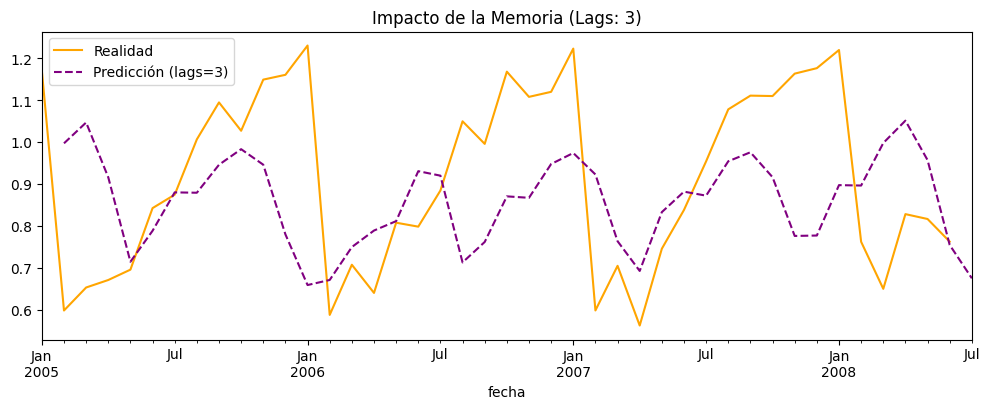

In [7]:
# EJERCICIO 1: Juega con el valor de los lags

mis_lags = 3  # <-- CAMBIA ESTE NÚMERO (prueba 3, luego prueba 36)

mi_forecaster = ForecasterRecursive(
                regressor = RandomForestRegressor(random_state=42),
                lags      = mis_lags
             )

mi_forecaster.fit(y=datos_train['demanda_recursos'])
mis_predicciones = mi_forecaster.predict(steps=len(datos_test))

fig, ax = plt.subplots(figsize=(12, 4))
datos_test['demanda_recursos'].plot(ax=ax, label='Realidad', color='orange')
mis_predicciones.plot(ax=ax, label=f'Predicción (lags={mis_lags})', color='purple', linestyle='--')
ax.legend()
plt.title(f'Impacto de la Memoria (Lags: {mis_lags})')
plt.show()

## 🛠️ PAUSA PARA PENSAR (Ejercicio 2): El Poder del Algoritmo

Hasta ahora usamos `RandomForestRegressor`. Los árboles son geniales capturando no-linealidades, pero a veces son malos extrapolando tendencias a futuro (es decir, prediciendo valores más altos de los que jamás han visto en el entrenamiento).

**Tu Turno:**
¿Qué pasaría si usamos una vieja confiable regresión lineal (`Ridge`) en lugar de un Random Forest? ¿Será que un modelo más simple es mejor o peor para esta serie temporal?

## 🛠️ PAUSA PARA PENSAR (Ejercicio 3): El Efecto Mariposa (Horizonte de Predicción)

En los ejercicios anteriores le pedimos al modelo que predijera **36 meses seguidos** de un solo golpe (usando `steps=len(datos_test)`).
Piensen en cómo funciona esto por debajo: predice el mes 1, luego **usa esa predicción** como dato histórico para predecir el mes 2, y así sucesivamente. ¡El error se acumula como una bola de nieve!

**Tu Turno:**
Cambiemos el horizonte. ¿Qué pasa si solo le pedimos que mire 3 meses hacia el futuro en lugar de 36? Modifica la variable `mis_pasos` a **3**, luego a **12**, y nota cómo la predicción al principio es casi perfecta, pero se degrada con el tiempo.

In [9]:
# EJERCICIO 2: Cambiando el motor bajo el capó

from sklearn.linear_model import Ridge

# 1. Instancia el Forecaster usando Ridge() en lugar de RandomForestRegressor
forecaster_lineal = ForecasterRecursive(
                regressor = Ridge(), # <-- Aquí cambiamos el algoritmo
                lags      = 15
             )

# 2. Entrena y predice
forecaster_lineal.fit(y=datos_train['demanda_recursos'])
pred_lineal = forecaster_lineal.predict(steps=len(datos_test))

# 3. Compara
fig, ax = plt.subplots(figsize=(12, 4))
datos_test['demanda_recursos'].plot(ax=ax, label='Realidad', color='orange')
predicciones.plot(ax=ax, label='Random Forest', color='red', linestyle='--')
pred_lineal.plot(ax=ax, label='Ridge (Lineal)', color='green', linestyle='-.')
ax.legend()
plt.title('Random Forest vs Modelo Lineal')
plt.show()z

SyntaxError: invalid syntax (2731697127.py, line 22)

## La Realidad: Backtesting (Evaluación Robusta)

Sé lo que están pensando como estadísticos: *"Ver gráficas es lindo, pero necesito números. Necesito Validar mi modelo"*.

En Machine Learning tabular usamos Validación Cruzada Aleatoria (K-Fold CV). **En series de tiempo, hacer eso es un pecado capital**. Si mezclamos el año 2004 con el 2001 al azar, le estamos dando respuestas futuras a un modelo pasado. Es hacer trampa.

En lugar de eso, usamos **Backtesting**:
1. Entrenamos con el pasado.
2. Predecimos un mes (o unos pocos meses).
3. Avanzamos el reloj un mes en el futuro, incluimos ese mes en nuestros datos de entrenamiento y volvemos a predecir.
4. Repetimos.

Suena complejo de programar, pero `skforecast` nos lo regala en una función:

In [ ]:
from skforecast.model_selection import backtesting_forecaster
from skforecast.model_selection import TimeSeriesFold

# Vamos a evaluar nuestro Random Forest original usando Backtesting
# Simularemos que predecimos la demanda de recursos cada 6 meses, avanzamos, y re-entrenamos.

cv = TimeSeriesFold(
         steps              = 6,     # Predecimos de 6 en 6 meses
         initial_train_size = len(datos_train),
         refit              = True,  # Re-entrenamos al avanzar
         fixed_train_size   = False, # Falso = el modelo aprende mes a mes de los datos nuevos

     )

metrica, predicciones_backtest = backtesting_forecaster(
                                    forecaster         = forecaster,
                                    y                  = datos['demanda_recursos'],
                                    cv                 = cv,
                                    metric             = 'mean_absolute_error', # MAE: Error absoluto medio (Camas de diferencia)
                                    verbose            = True
                                 )

print(f"\nError Absoluto Medio (MAE) del Backtesting:")
print(metrica)

fig, ax = plt.subplots(figsize=(12, 4))
datos_test['demanda_recursos'].plot(ax=ax, label='Realidad')
predicciones_backtest.plot(ax=ax, label='Predicciones Backtesting', color='purple')
ax.legend()
plt.title('Backtesting: Cómo funcionaría el modelo en la vida real')
plt.show()

## 🛠️ PAUSA PARA PENSAR (Ejercicio 4): El Contexto Externo (Variables Exógenas)

Hasta ahora nuestro modelo es puramente **Autoregresivo** (solo mira la demanda pasada). Pero en la vida real de un hospital, hay cosas que dictan la demanda independientemente de lo que pasó ayer. Por ejemplo: **El mes del año** (en invierno hay más urgencias respiratorias).

`skforecast` nos permite agregar variables externas (exógenas) sin esfuerzo.

**Tu Turno:**
Vamos a extraer el "mes" de nuestra fecha y pasárselo al modelo. Observen cómo cambia la inicialización, el entrenamiento y la predicción al incluir `exog`.

In [ ]:
# EJERCICIO 4: Agregando el "Mes" como variable exógena
# 1. Creamos la variable exógena en nuestros datos originales
datos['mes_del_anio'] = datos.index.month

# 2. Separamos de nuevo (train/test) para incluir la nueva columna
datos_train = datos.loc[:fin_entrenamiento]
datos_test  = datos.loc[fin_entrenamiento:]

# 3. Entrenamos (Noten el parámetro 'exog')
forecaster.fit(
    y    = datos_train['demanda_recursos'],
    exog = datos_train['mes_del_anio']  # <-- ¡Aquí le pasamos el contexto externo!
)

# 4. Predecimos (Debemos pasarle el calendario futuro 'exog' para que pueda predecir)
pred_exog = forecaster.predict(
    steps = len(datos_test),
    exog  = datos_test['mes_del_anio']  # <-- El modelo necesita saber qué meses vienen
)

# 5. Visualizamos
fig, ax = plt.subplots(figsize=(12, 4))
datos_test['demanda_recursos'].plot(ax=ax, label='Realidad', color='orange')
predicciones.plot(ax=ax, label='RF (Solo Lags)', color='gray', linestyle='--')
pred_exog.plot(ax=ax, label='RF (Lags + Mes Exógeno)', color='blue', linewidth=2)
ax.legend()
plt.title('Impacto de agregar el Mes como Variable Exógena')
plt.show()

## 🛠️ PAUSA PARA PENSAR (Ejercicio 5): El Trabajo del Científico de Datos (Grid Search)

Como científicos de datos, nosotros no "adivinamos" si el mejor lag es 15 o si el `max_depth` del Random Forest debe ser 3 o 10. ¡Nosotros calculamos eso!

El problema en series temporales es que optimizar los hiperparámetros del modelo (ej. `n_estimators`) interactúa con la cantidad de rezagos (`lags`). Afortunadamente, no tenemos que hacer bucles for interminables; `skforecast` tiene una función de búsqueda (Grid Search) que respeta la línea de tiempo.

**Tu Turno:**
Ejecuta la siguiente celda. Vamos a pedirle a la máquina que pruebe combinaciones de `lags` (5, 12, 24) y profundidades del árbol (`max_depth` 3 y 5), usando el Backtesting de fondo para darnos el ganador absoluto.

In [ ]:
# EJERCICIO 5 (CORREGIDO): Encontrando el modelo perfecto con TimeSeriesFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import TimeSeriesFold

# 1. Definimos qué queremos buscar
lags_grid =[5, 12, 24] # Probaremos darle memoria de 5, 12 o 24 meses
param_grid = {'max_depth': [3, 5, 10]} # Probaremos árboles poco y muy profundos

# Creamos un forecaster limpio
forecaster_grid = ForecasterRecursive(
                    regressor = RandomForestRegressor(random_state=42),
                    lags      = 12 # Esto se sobrescribirá en la búsqueda
                 )

# 2. Definimos LAS REGLAS DEL JUEGO para evaluar cada combinación (Backtesting interno)
# ¡Aquí usamos la sintaxis moderna con TimeSeriesFold!
cv_grid = TimeSeriesFold(
    steps              = 6,
    initial_train_size = len(datos_train),
    refit              = False,  # Falso para que la búsqueda sea más rápida
    fixed_train_size   = False
)

print("Iniciando búsqueda de hiperparámetros. Esto puede tomar unos segundos...\n")

# 3. Ejecutamos la búsqueda pasándole nuestro objeto 'cv_grid'
resultados_grid = grid_search_forecaster(
                        forecaster  = forecaster_grid,
                        y           = datos['demanda_recursos'],
                        param_grid  = param_grid,
                        lags_grid   = lags_grid,
                        cv          = cv_grid,                 # <-- La forma correcta y moderna
                        metric      = 'mean_absolute_error',
                        return_best = True,                    # ¡Que nos devuelva el modelo ganador entrenado!
                        verbose     = False
                   )

# 4. ¿Quién ganó?
print("¡Búsqueda terminada!\n")
print(f"Mejores Lags encontrados: {forecaster_grid.lags}")
print("Top 3 de combinaciones evaluadas:")
display(resultados_grid[['lags', 'params', 'mean_absolute_error']].head(3))

## 🎓 Conclusión

¡Felicidades! Acaban de resolver uno de los problemas más complejos de la industria.

Recapitulemos lo que lograron hoy:
1. Comprendieron que **el tiempo no existe para los algoritmos clásicos**. Nosotros creamos el tiempo usando la técnica de ventana deslizante (**Lags**).
2. Descubrieron que el **algoritmo no lo es todo**. Cambiar la "memoria" (lags) puede tener un impacto mucho mayor que cambiar de Random Forest a Ridge.
3. Aprendieron a no engañarse a sí mismos. Usar **Backtesting** es la única forma ética y matemáticamente correcta de evaluar una serie de tiempo.

*"El Machine Learning no se trata de quién escribe el código más complejo, sino de quién entiende mejor cómo los datos representan la realidad."*

Si quieren profundizar, les recomiendo buscar cómo usar `grid_search_forecaster` en la documentación oficial de `skforecast` para buscar automáticamente la mejor combinación de Lags y parámetros del modelo. ¡Gran trabajo hoy!